In [3]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import pandas as pd

In [4]:
df = pd.read_csv('choco_monthly_revenue.csv', index_col=0, parse_dates=True)
df.head()

,revenue
Month with Year,
2018-01-01,1458
2018-02-01,1102
2018-03-01,1584
2018-04-01,1676
2018-05-01,1461


In [5]:
df

,revenue
Month with Year,
2018-01-01,1458
2018-02-01,1102
2018-03-01,1584
2018-04-01,1676
2018-05-01,1461
2018-06-01,1491
2018-07-01,1376
2018-08-01,1209
2018-09-01,1668


In [6]:
df.index

DatetimeIndex(['2018-01-01', '2018-02-01', '2018-03-01', '2018-04-01',
               '2018-05-01', '2018-06-01', '2018-07-01', '2018-08-01',
               '2018-09-01', '2018-10-01', '2018-11-01', '2018-12-01',
               '2019-01-01', '2019-02-01', '2019-03-01', '2019-04-01',
               '2019-05-01', '2019-06-01', '2019-07-01', '2019-08-01',
               '2019-09-01', '2019-10-01', '2019-11-01', '2019-12-01',
               '2020-01-01', '2020-02-01', '2020-03-01', '2020-04-01',
               '2020-05-01', '2020-06-01', '2020-07-01', '2020-08-01',
               '2020-09-01', '2020-10-01', '2020-11-01', '2020-12-01',
               '2021-01-01', '2021-02-01', '2021-03-01', '2021-04-01',
               '2021-05-01', '2021-06-01', '2021-07-01', '2021-08-01',
               '2021-09-01', '2021-10-01', '2021-11-01', '2021-12-01',
               '2022-01-01', '2022-02-01', '2022-03-01', '2022-04-01',
               '2022-05-01', '2022-06-01', '2022-07-01', '2022-08-01',
      

<AxesSubplot:xlabel='Month with Year'>

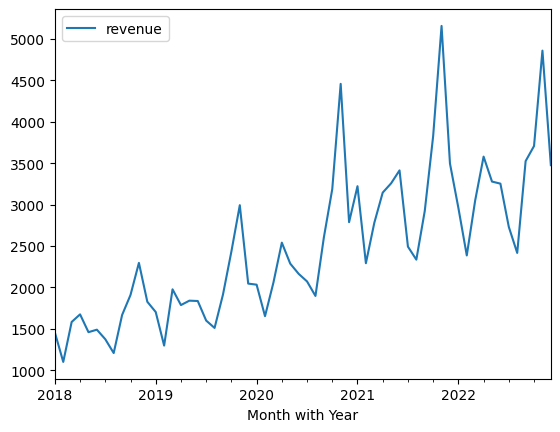

In [7]:
df.asfreq('MS')
df.plot()

In [8]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import month_plot

In [9]:
decomposition = seasonal_decompose(df.revenue, model='multiplicative',period=12)

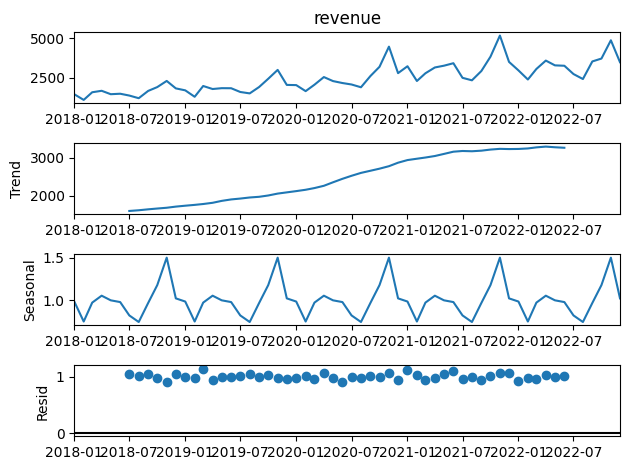

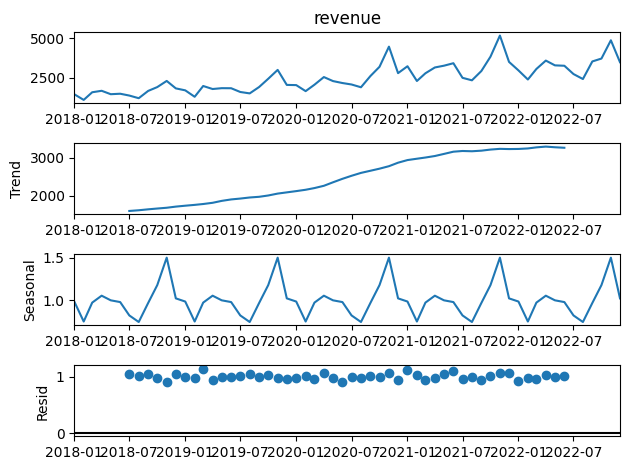

In [10]:
decomposition.plot()

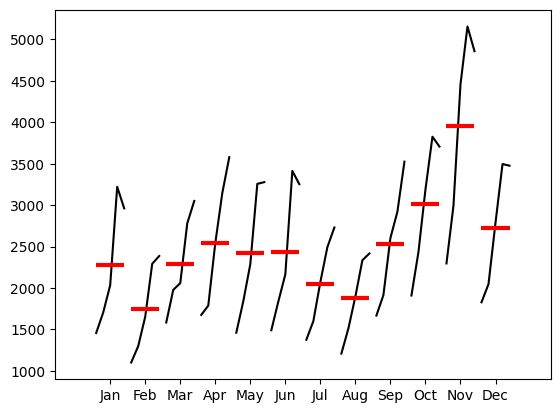

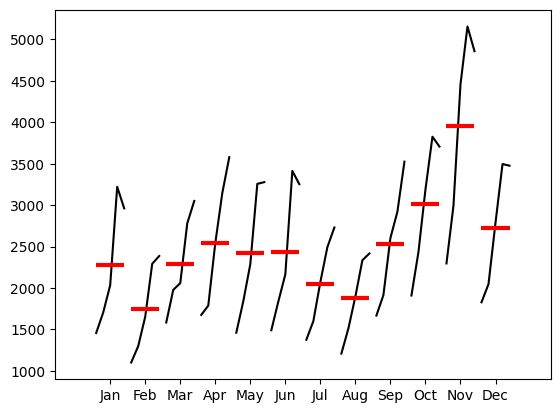

In [11]:
month_plot(df.revenue)

In [12]:
from statsmodels.graphics.tsaplots import plot_acf

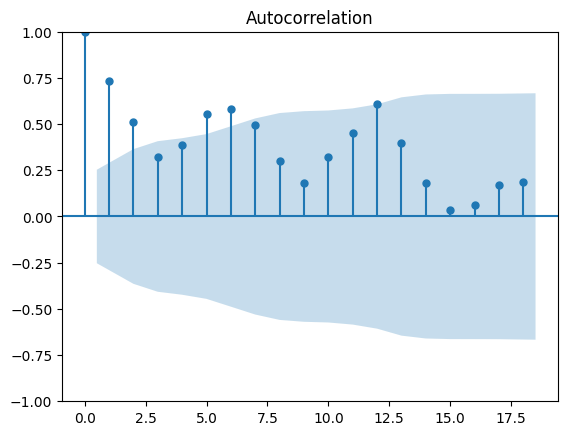

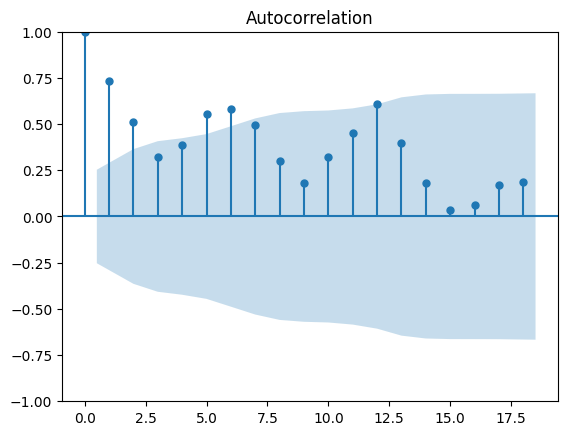

In [13]:
plot_acf(df.revenue)

In [14]:
test_months = 3
training = df.iloc[:-test_months,:]
test = df.iloc[-test_months:,:]
model = ExponentialSmoothing(endog=training.revenue,trend='add',seasonal='add',seasonal_periods=12,freq='MS').fit()

In [15]:
predictions =model.forecast(steps=len(test)).rename('Prediction')
predictions.head()

2022-10-01    3832.844979
2022-11-01    4717.700505
2022-12-01    3521.448155
Freq: MS, Name: Prediction, dtype: float64

<AxesSubplot:xlabel='Month with Year'>

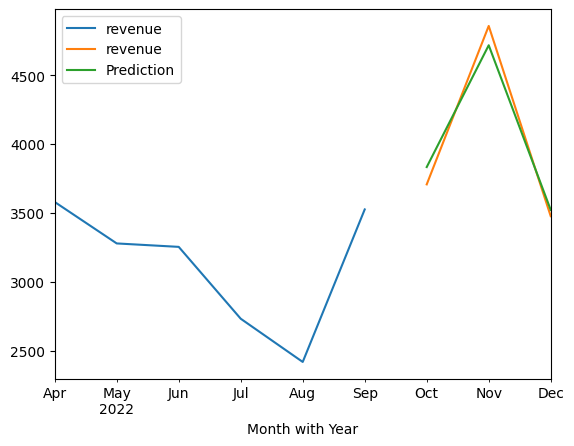

In [16]:
training.revenue.iloc[-6:].plot(legend=True)
test.revenue.plot(legend=True)
predictions.plot(legend=True)

In [17]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [18]:
print(mean_absolute_error(test['revenue'],predictions))
print(mean_squared_error(test['revenue'],predictions))

103.8642099154099
12528.813987234937


<AxesSubplot:xlabel='Month with Year'>

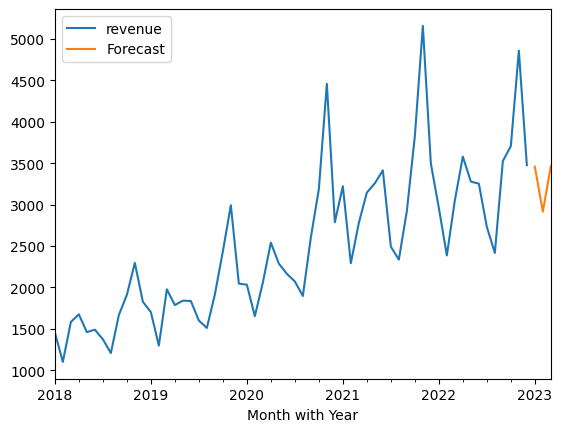

In [19]:
model2 = ExponentialSmoothing(endog=df.revenue,trend='add',seasonal='add',seasonal_periods=12,freq='MS').fit()
fcast =model2.forecast(steps=3).rename('Forecast')
df.plot(legend=True)
fcast.plot(legend=True)